DSCI 552 Homework 2
===================

- Name: Umaeshwer Shankar
- GitHub Username: umaeshwer
- USD ID: 7601-5514-88

## Importing Libraries

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import sklearn

## 1. Combined Cycle Power Plant Data Set

### a) Reading the Combined Cycle Power Plant Data Set

In [33]:
df = pd.read_excel('../data/Folds5x2_pp.xlsx')

In [34]:
df.head()

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


### b) Exploring the data

i. How many rows are in this data set? How many columns? What do the rows and columns represent?

In [35]:
df.shape

(9568, 5)

Answer: There are 9658 rows and 5 columns. The rows represent the observations collected and the columns represent the features.

ii. Make pairwise scatterplots of all the variables in the data set including the predictors (independent variables) with the dependent variable. Describe your findings.

/var/folders/5c/3qs4gb0n2jjb1nf6m8w53dvh0000gn/T/ipykernel_98703/3886709304.py:5: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  pd.plotting.scatter_matrix(df, c=df['PE'], marker='o', cmap='bwr', ax=fig.add_subplot(111))


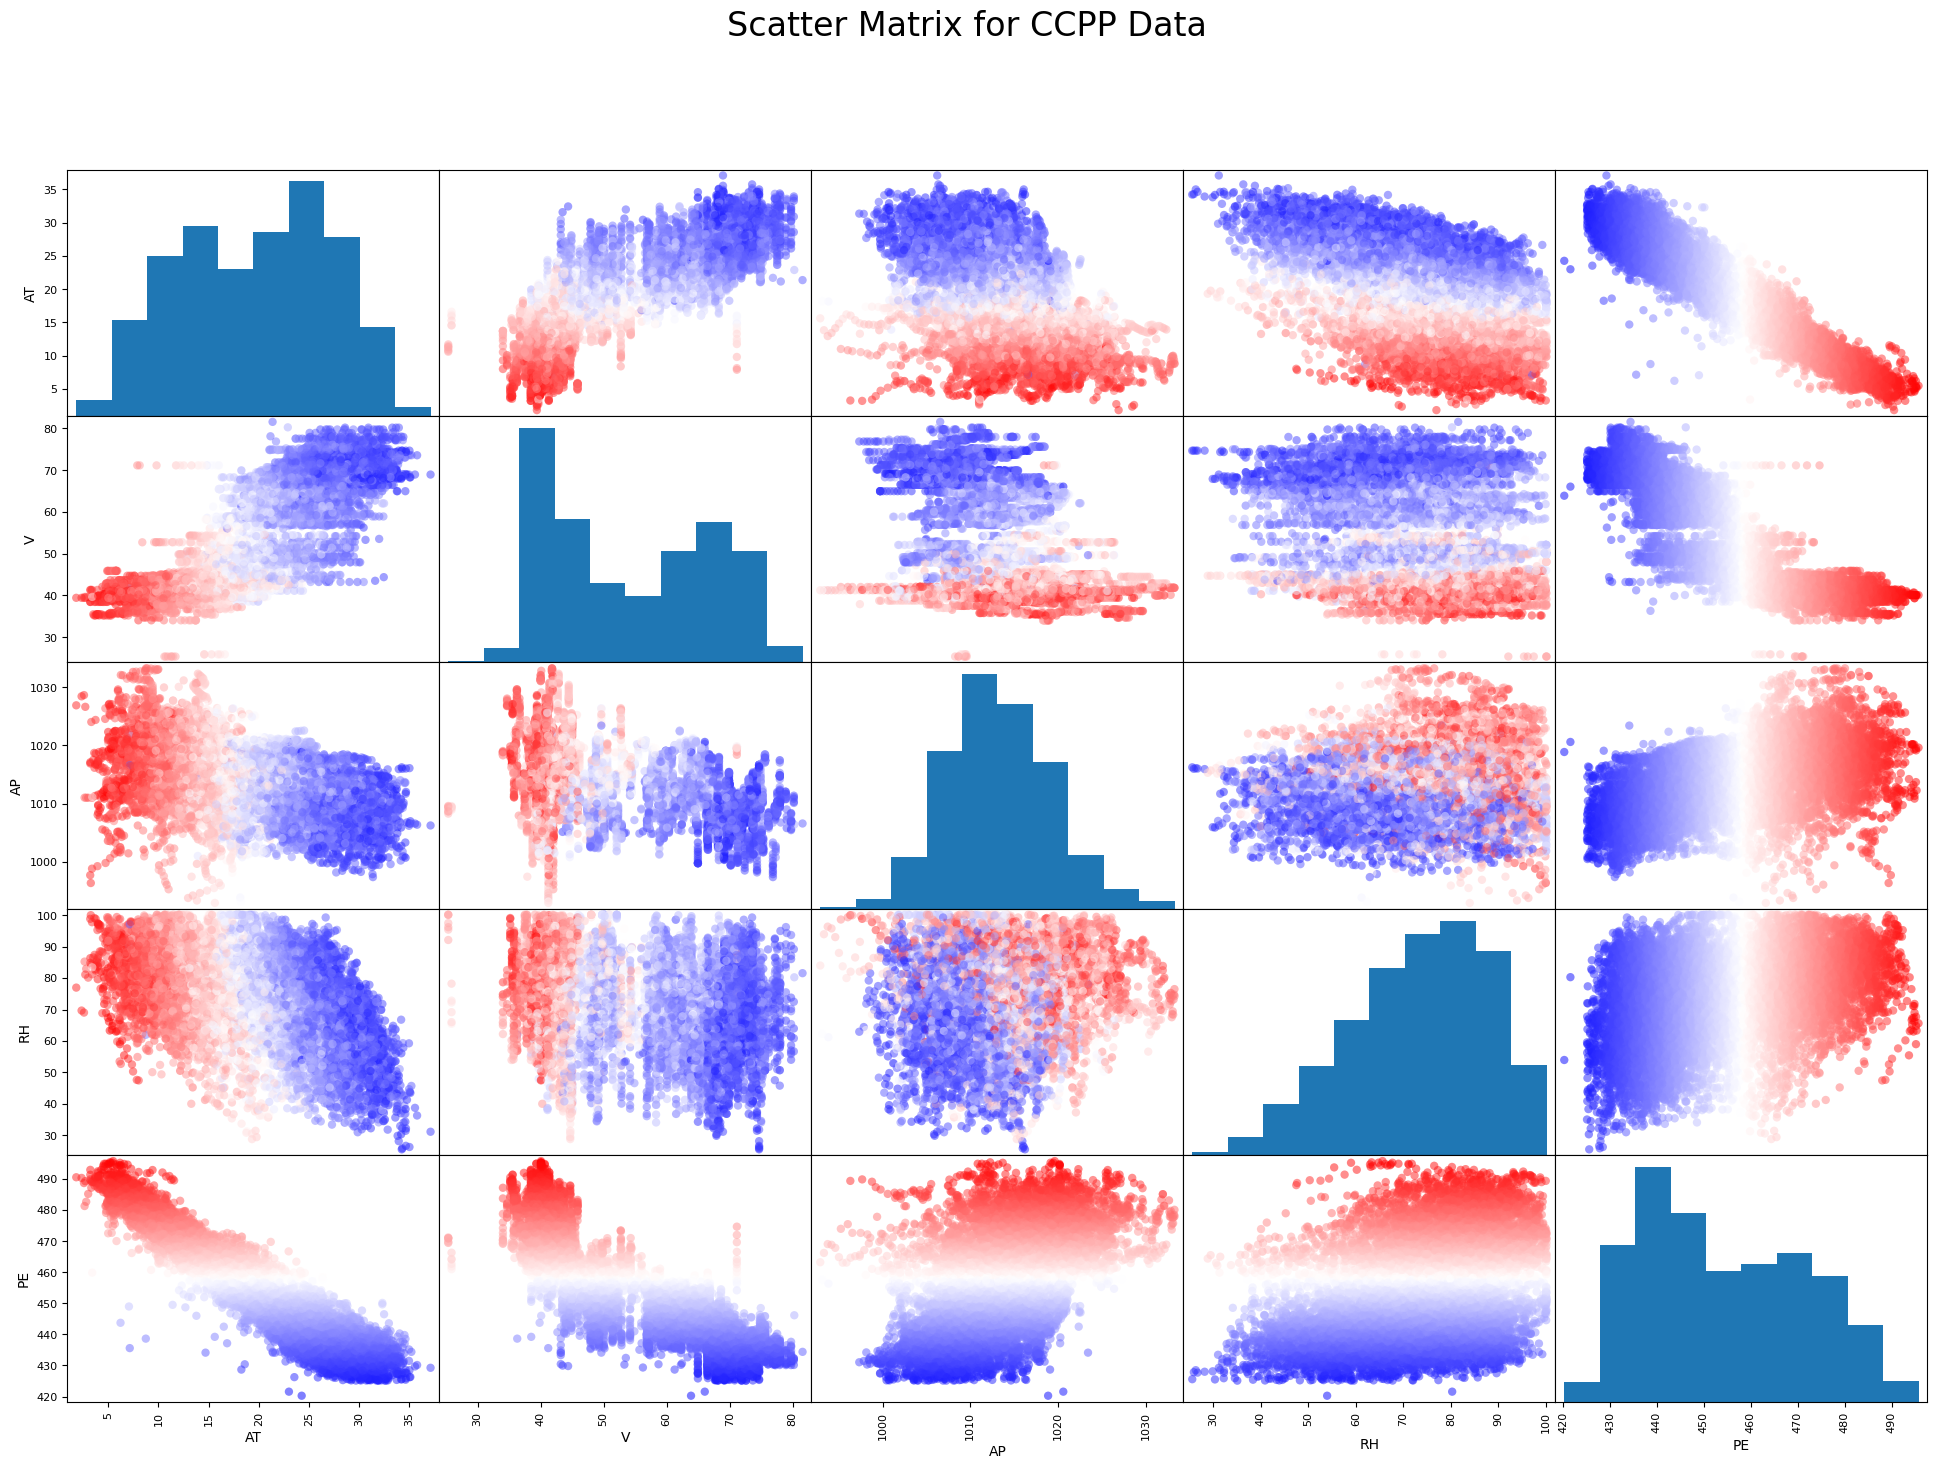

In [36]:
"""
Reference Link: https://pandas.pydata.org/docs/reference/api/pandas.plotting.scatter_matrix.html
"""
fig = plt.figure(figsize=(24, 16))
pd.plotting.scatter_matrix(df, c=df['PE'], marker='o', cmap='bwr', ax=fig.add_subplot(111))
plt.suptitle('Scatter Matrix for CCPP Data', fontsize=24)
plt.show()

Findings:

- AT and V have a strong positive correlation
- AT and V have negative correlation with PE, the variable we are trying to predict

iii. What are the mean, the median, range, first and third quartiles, and interquartile ranges of each of the variables in the dataset? Summarize them in a table.

In [37]:
# df.describe()
res = pd.DataFrame({
    "mean": df.mean(),
    "median": df.median(),
    "range": df.max() - df.min(),
    "First Quartile": df.quantile(0.25),
    "Third Quartile": df.quantile(0.75),
    "IQR": df.quantile(0.75) - df.quantile(0.25)
})

display(res)

,mean,median,range,First Quartile,Third Quartile,IQR
AT,19.651231,20.345,35.30,13.5100,25.72,12.2100
V,54.305804,52.080,56.20,41.7400,66.54,24.8000
AP,1013.259078,1012.940,40.41,1009.1000,1017.26,8.1600
RH,73.308978,74.975,74.60,63.3275,84.83,21.5025
PE,454.365009,451.550,75.50,439.7500,468.43,28.6800


### c) For each predictor, fit a simple linear regression model to predict the response. Describe your results. In which of the models is there a statistically significant association between the predictor and the response? Create some plots to back up your assertions. Are there any outliers that you would like to remove from your data for each of these regression tasks? 

In [38]:
# train-test split
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(df.drop(columns=['PE']), df['PE'], test_size=0.2)

In [39]:
coeff = {}
outlier_threshold = 0.025

def single_variable_ols(feature):
    model = sm.OLS(y_train, sm.add_constant(X_train[feature])).fit()
    print(model.summary())
    coeff[feature] = model.params[feature]

    fig = plt.figure(figsize=(12, 8))
    sns.regplot(x=X_train[feature], y=y_train, line_kws={"color": "red"})
    plt.title(f'{feature} vs PE', fontsize=16)
    plt.xlabel(feature, fontsize=14)
    plt.ylabel('PE', fontsize=14)
    plt.show()

    outliers = model.outlier_test()
    outliers = outliers[outliers['bonf(p)'] < outlier_threshold]
    display(outliers)

    X_predict_train = model.predict(sm.add_constant(X_train[feature]))
    X_predict_test = model.predict(sm.add_constant(X_train[feature]))

    train_error = np.mean((y_train - X_predict_train) ** 2)
    test_error = np.mean((y_test - X_predict_test) ** 2)

    print(f'Train Error: {train_error}')
    print(f'Test Error: {test_error}')

    return coeff

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.899
Model:                            OLS   Adj. R-squared:                  0.899
Method:                 Least Squares   F-statistic:                 6.806e+04
Date:                Fri, 13 Feb 2026   Prob (F-statistic):               0.00
Time:                        11:43:41   Log-Likelihood:                -23809.
No. Observations:                7654   AIC:                         4.762e+04
Df Residuals:                    7652   BIC:                         4.764e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        497.0775      0.175   2841.452      0.0

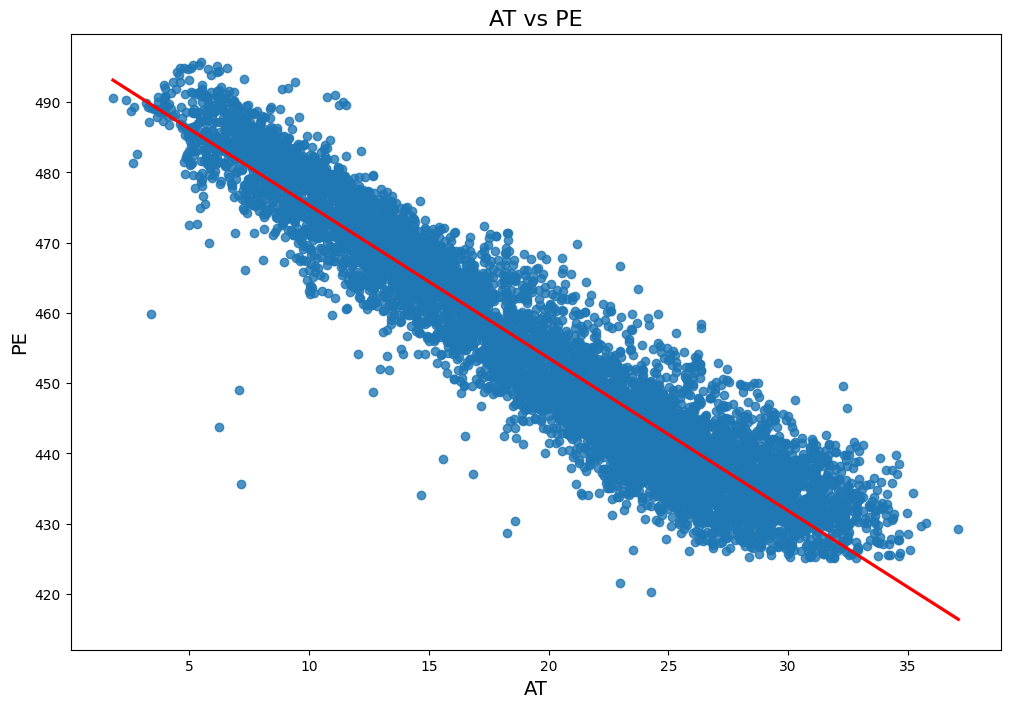

,student_resid,unadj_p,bonf(p)
8187,-5.295523,1.219774e-07,9.336153e-04
3895,-5.724190,1.078559e-08,8.255292e-05
7375,-4.842153,1.309601e-06,1.002369e-02
7664,-8.508018,2.107306e-17,1.612932e-13
4218,-4.702024,2.621057e-06,2.006157e-02
7398,-6.048053,1.534993e-09,1.174883e-05
8362,-5.505242,3.806062e-08,2.913160e-04
3383,-7.361449,2.008576e-13,1.537364e-09


Train Error: 29.47521244034334
Test Error: nan


In [40]:
# Case 1: AT
coeff = single_variable_ols('AT')

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.759
Model:                            OLS   Adj. R-squared:                  0.759
Method:                 Least Squares   F-statistic:                 2.408e+04
Date:                Fri, 13 Feb 2026   Prob (F-statistic):               0.00
Time:                        11:43:46   Log-Likelihood:                -27137.
No. Observations:                7654   AIC:                         5.428e+04
Df Residuals:                    7652   BIC:                         5.429e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        517.7568      0.419   1234.838      0.0

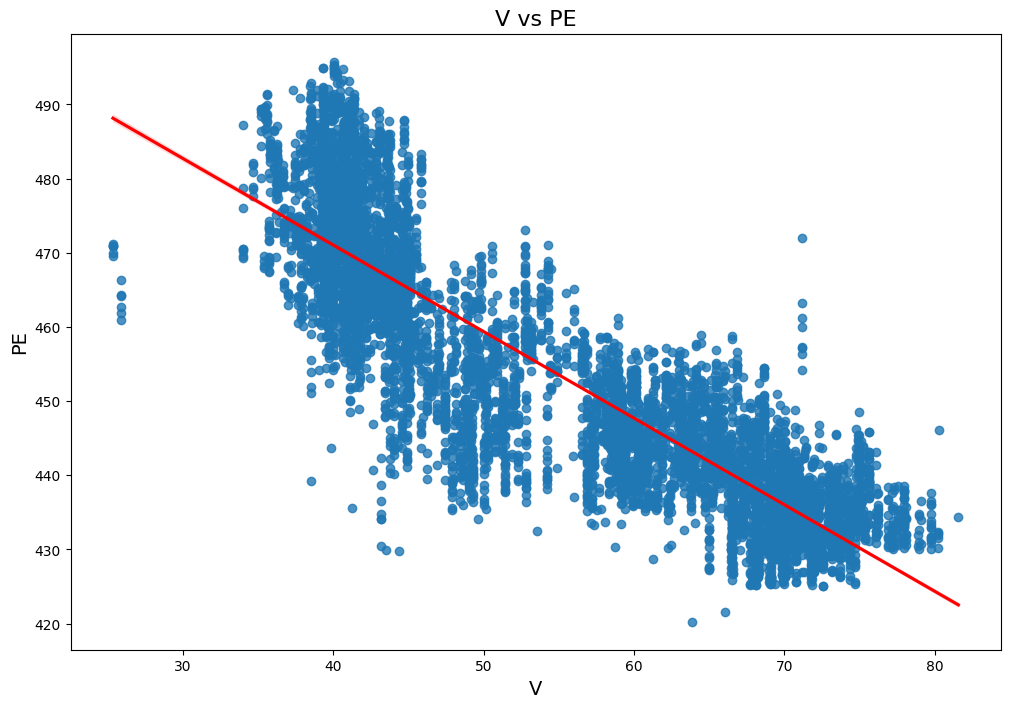

,student_resid,unadj_p,bonf(p)


Train Error: 70.31273334997213
Test Error: nan


In [41]:
# Case 2: V
coeff = single_variable_ols('V')

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.258
Model:                            OLS   Adj. R-squared:                  0.258
Method:                 Least Squares   F-statistic:                     2662.
Date:                Fri, 13 Feb 2026   Prob (F-statistic):               0.00
Time:                        11:43:52   Log-Likelihood:                -31438.
No. Observations:                7654   AIC:                         6.288e+04
Df Residuals:                    7652   BIC:                         6.289e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1024.1591     28.660    -35.735      0.0

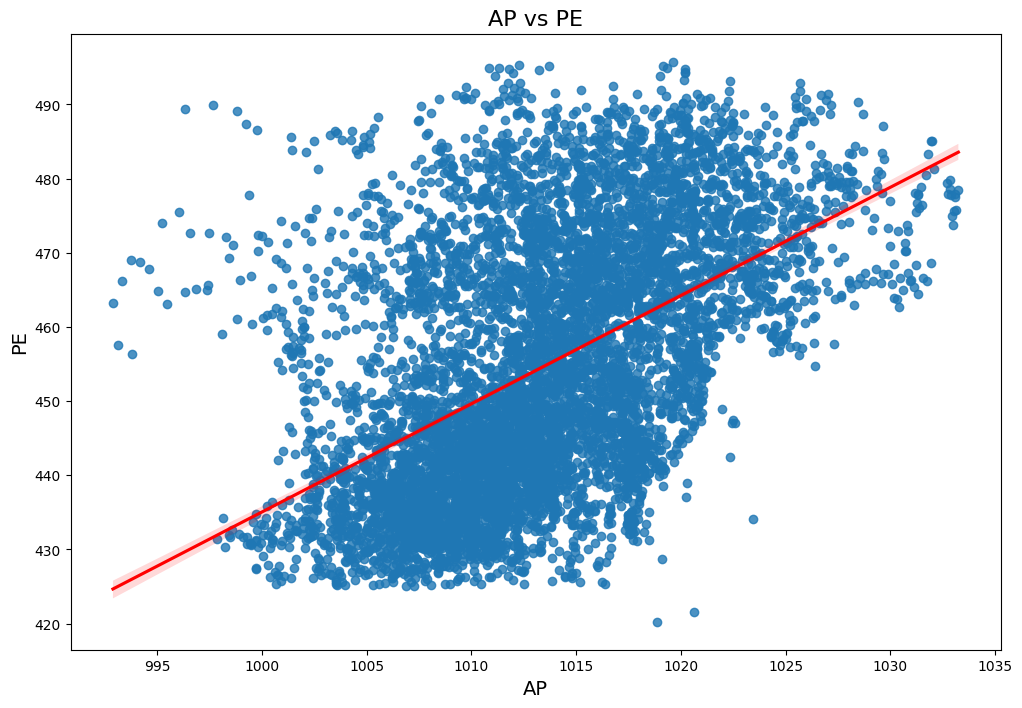

,student_resid,unadj_p,bonf(p)


Train Error: 216.36207922626392
Test Error: nan


In [42]:
# Case 3: AP
coeff = single_variable_ols('AP')

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.154
Model:                            OLS   Adj. R-squared:                  0.154
Method:                 Least Squares   F-statistic:                     1390.
Date:                Fri, 13 Feb 2026   Prob (F-statistic):          9.81e-280
Time:                        11:43:58   Log-Likelihood:                -31942.
No. Observations:                7654   AIC:                         6.389e+04
Df Residuals:                    7652   BIC:                         6.390e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        421.0227      0.913    461.001      0.0

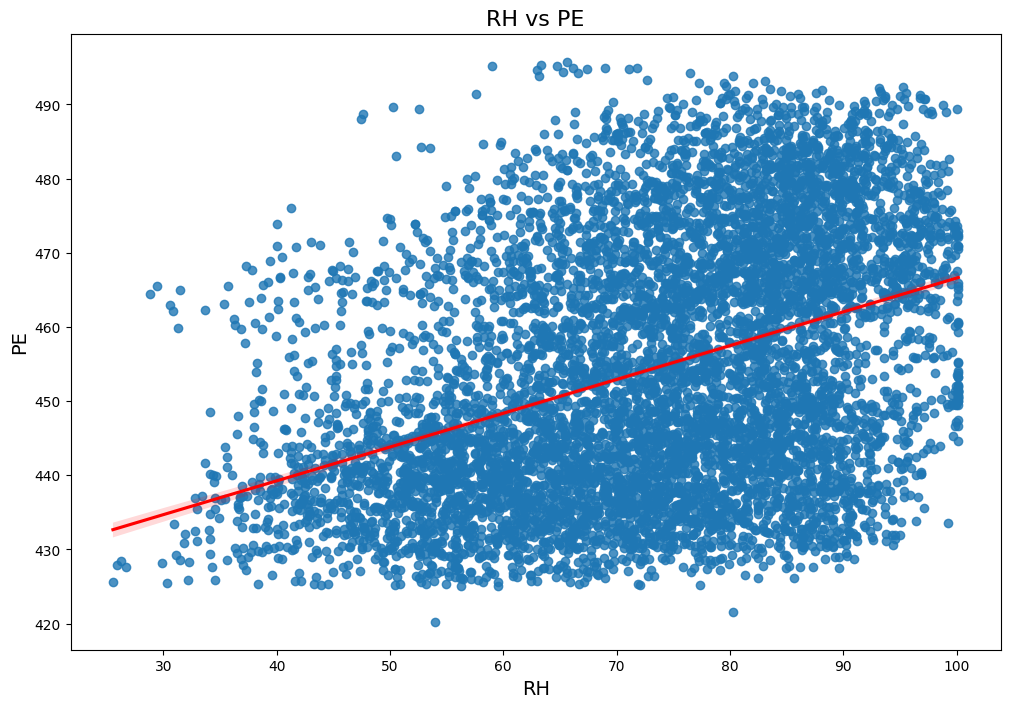

,student_resid,unadj_p,bonf(p)


Train Error: 246.787401018575
Test Error: nan


In [43]:
# Case 4: RH
coeff = single_variable_ols('RH')

Answer:

- AT vs PE has few outliers but other features do not have them
- Test errors are too high

### d) Fit a multiple regression model to predict the response using all of the predictors. Describe your results. For which predictors can we reject the null hypothesis H0 : βj = 0?

In [44]:
model = sm.OLS(y_train, X_train).fit()
print(model.summary())

X_predict_train = model.predict(X_train)
X_predict_test = model.predict(X_test)

train_error = np.mean((y_train - X_predict_train) ** 2)
test_error = np.mean((y_test - X_predict_test) ** 2)

print(f'Train Error: {train_error}')
print(f'Test Error: {test_error}')

                                 OLS Regression Results                                
Dep. Variable:                     PE   R-squared (uncentered):                   1.000
Model:                            OLS   Adj. R-squared (uncentered):              1.000
Method:                 Least Squares   F-statistic:                          1.539e+07
Date:                Fri, 13 Feb 2026   Prob (F-statistic):                        0.00
Time:                        11:44:04   Log-Likelihood:                         -23285.
No. Observations:                7654   AIC:                                  4.658e+04
Df Residuals:                    7650   BIC:                                  4.661e+04
Df Model:                           4                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

Answer:

- Since the p-value is 0 for all the features, we can reject the null hypothesis

### e) How do your results from 1c compare to your results from 1d? Create a plot displaying the univariate regression coeﬃcients from 1c on the x-axis, and the multiple regression coeﬃcients from 1d on the y-axis. That is, each predictor is displayed as a single point in the plot. Its coeﬃcient in a simple linear regression model is shown on the x-axis, and its coeﬃcient estimate in the multiple linear regression model is shown on the y-axis.

In [45]:
print(coeff)

{'AT': np.float64(-2.1744996149702462), 'V': np.float64(-1.1675614820709384), 'AP': np.float64(1.4592066082824955), 'RH': np.float64(0.45568115451572694)}


In [46]:
multi_coeff = dict(model.params)
print(multi_coeff)

{'AT': np.float64(-1.6771921928114946), 'V': np.float64(-0.2761223417306015), 'AP': np.float64(0.5028306250175353), 'RH': np.float64(-0.09844200606820827)}


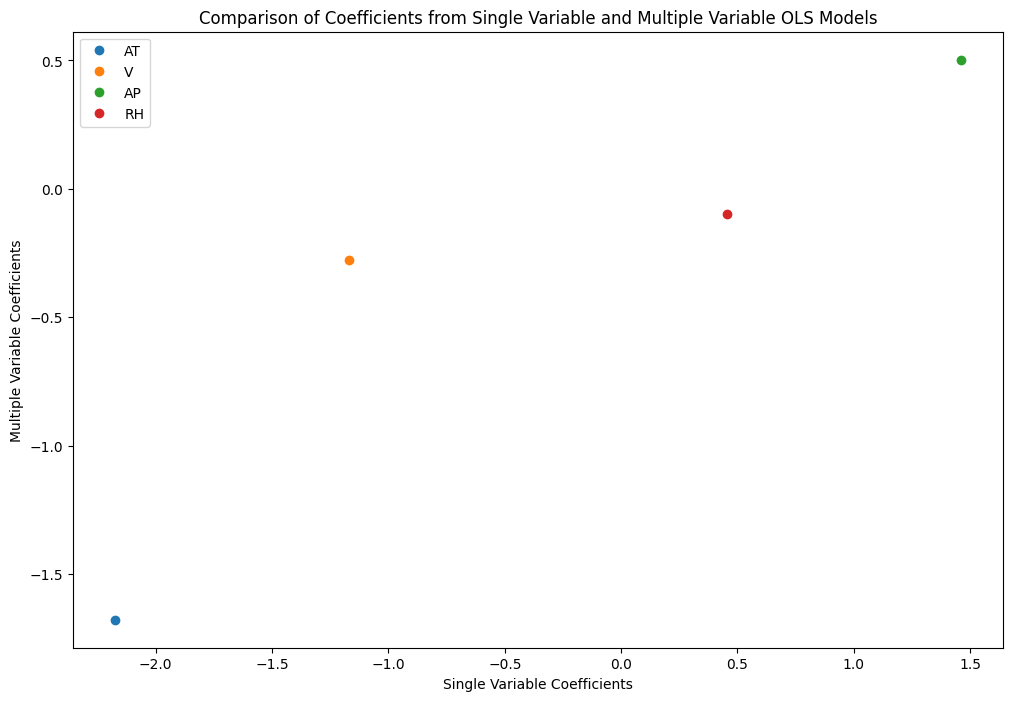

In [47]:
fig = plt.figure(figsize=(12, 8))
for key in coeff.keys():
    plt.plot(coeff[key], multi_coeff[key], 'o', label=key)
plt.legend(coeff.keys())
plt.xlabel('Single Variable Coefficients')
plt.ylabel('Multiple Variable Coefficients')
plt.title('Comparison of Coefficients from Single Variable and Multiple Variable OLS Models')
plt.show()

### f) Is there evidence of nonlinear association between any of the predictors and the response? To answer this question, for each predictor X, fit a model of the form

Y= β0 + β1X+ β2X2 + β3X3 + ϵ

In [48]:
def poly_ols(feature):
    X = X_train[feature]
    X_poly = np.column_stack((X, X**2, X**3))
    X_poly = sm.add_constant(X_poly)
    X_test_poly = np.column_stack((X_test[feature], X_test[feature]**2, X_test[feature]**3))
    X_test_poly = sm.add_constant(X_test_poly)

    model = sm.OLS(y_train, X_poly).fit()
    print(model.summary())

    X_predict_train = model.predict(X_poly)
    X_predict_test = model.predict(X_test_poly)

    train_error = np.mean((y_train - X_predict_train) ** 2)
    test_error = np.mean((y_test - X_predict_test) ** 2)

    print(f'Train Error: {train_error}')
    print(f'Test Error: {test_error}')

In [49]:
# Case 1: AT
poly_ols('AT')

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.912
Model:                            OLS   Adj. R-squared:                  0.912
Method:                 Least Squares   F-statistic:                 2.640e+04
Date:                Fri, 13 Feb 2026   Prob (F-statistic):               0.00
Time:                        11:44:04   Log-Likelihood:                -23283.
No. Observations:                7654   AIC:                         4.657e+04
Df Residuals:                    7650   BIC:                         4.660e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        492.6148      0.751    655.601      0.0

In [50]:
# Case 2: V
poly_ols('V')

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.777
Model:                            OLS   Adj. R-squared:                  0.777
Method:                 Least Squares   F-statistic:                     8900.
Date:                Fri, 13 Feb 2026   Prob (F-statistic):               0.00
Time:                        11:44:04   Log-Likelihood:                -26833.
No. Observations:                7654   AIC:                         5.367e+04
Df Residuals:                    7650   BIC:                         5.370e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        547.3478      9.966     54.919      0.0

In [51]:
# Case 3: AP
poly_ols('AP')

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.265
Model:                            OLS   Adj. R-squared:                  0.265
Method:                 Least Squares   F-statistic:                     1382.
Date:                Fri, 13 Feb 2026   Prob (F-statistic):               0.00
Time:                        11:44:04   Log-Likelihood:                -31400.
No. Observations:                7654   AIC:                         6.281e+04
Df Residuals:                    7651   BIC:                         6.283e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0827      0.010      8.276      0.0

In [52]:
# Case 4: RH
poly_ols('RH')

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.156
Model:                            OLS   Adj. R-squared:                  0.155
Method:                 Least Squares   F-statistic:                     470.0
Date:                Fri, 13 Feb 2026   Prob (F-statistic):          2.63e-280
Time:                        11:44:04   Log-Likelihood:                -31933.
No. Observations:                7654   AIC:                         6.387e+04
Df Residuals:                    7650   BIC:                         6.390e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        467.7587     11.497     40.686      0.0

Answer:

- The p-values are close to zero to reject the null hypothesis that there is non-linear association

### g) Is there evidence of association of interactions of predictors with the response? To answer this question, run a full linear regression model with all pairwise interaction terms and state whether any interaction terms are statistically significant.

In [53]:
train_df = pd.concat([X_train, y_train], axis=1)

In [54]:
pairwise_terms = 'PE ~ AT*V + AT*AP + AT*RH + V*AP + V*RH + AP*RH'
model = sm.OLS.from_formula(pairwise_terms, data=train_df).fit()
print(model.summary())

X_predict_train = model.predict(X_train)
X_predict_test = model.predict(X_test)

train_error = np.mean((y_train - X_predict_train) ** 2)
test_error = np.mean((y_test - X_predict_test) ** 2)

print(f'Train Error: {train_error}')
print(f'Test Error: {test_error}')

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.937
Model:                            OLS   Adj. R-squared:                  0.937
Method:                 Least Squares   F-statistic:                 1.131e+04
Date:                Fri, 13 Feb 2026   Prob (F-statistic):               0.00
Time:                        11:44:04   Log-Likelihood:                -22018.
No. Observations:                7654   AIC:                         4.406e+04
Df Residuals:                    7643   BIC:                         4.413e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    719.5817     86.139      8.354      0.0

Answer:

- AT:V, AT:RH, V:AP have p-value close to zero so we can reject the null hypothesis
- AT:AP and AP:RH have p-value less than 0.05 so if threshold is at 0.05 we will have to consider the association
- V:RH has p-value of 0.086 so if threshold is at 0.1 we will have to consider this association along with the ones for < 0.05

### h) Can you improve your model using possible interaction terms or nonlinear associations between the predictors and response? Train the regression model on a randomly selected 70% subset of the data with all predictors. Also, run a regression model involving all possible interaction terms and quadratic nonlinearities, and remove insignificant variables using p-values (be careful about interaction terms). Test both models on the remaining points and report your train and test MSEs.

In [55]:
# train-test split
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(df.drop(columns=['PE']), df['PE'], test_size=0.3)

train_df = pd.concat([X_train, y_train], axis=1)

In [56]:
# Case 1: All interaction and non-linear terms
interaction_nonlinear_terms = 'PE ~ AT + V + AP + RH + AT*V + AT*AP + AT*RH + V*AP + V*RH + AP*RH + np.power(AT, 2) + np.power(V, 2) + np.power(AP, 2) + np.power(RH, 2) + np.power(AT, 3) + np.power(V, 3) + np.power(AP, 3) + np.power(RH, 3)'
model = sm.OLS.from_formula(interaction_nonlinear_terms, data=train_df).fit()
print(model.summary())

X_predict_train = model.predict(X_train)
X_predict_test = model.predict(X_test)

train_error = np.mean((y_train - X_predict_train) ** 2)
test_error = np.mean((y_test - X_predict_test) ** 2)

print(f'Train Error: {train_error}')
print(f'Test Error: {test_error}')

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.939
Model:                            OLS   Adj. R-squared:                  0.939
Method:                 Least Squares   F-statistic:                     6050.
Date:                Fri, 13 Feb 2026   Prob (F-statistic):               0.00
Time:                        11:44:04   Log-Likelihood:                -19150.
No. Observations:                6697   AIC:                         3.834e+04
Df Residuals:                    6679   BIC:                         3.846e+04
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          -0.0202      0.004     

In [57]:
# Case 2: Removing terms using p-value threshold
pvalue_threshold = 0.05
while True:
    model = sm.OLS.from_formula(interaction_nonlinear_terms, data=train_df).fit()
    features = interaction_nonlinear_terms.split('~')[1].strip().split(' + ')
    p_values = model.pvalues
    max_p_value = p_values.max()
    if max_p_value > pvalue_threshold:
        worst_feature = p_values.idxmax()
        print(f'Removing feature: {worst_feature} with p-value: {max_p_value}')
        features.remove(worst_feature.replace(':', '*'))
        interaction_nonlinear_terms = 'PE ~ ' + ' + '.join(features)
    else:
        break
print(model.summary())

X_predict_train = model.predict(X_train)
X_predict_test = model.predict(X_test)

train_error = np.mean((y_train - X_predict_train) ** 2)
test_error = np.mean((y_test - X_predict_test) ** 2)

print(f'Train Error: {train_error}')
print(f'Test Error: {test_error}')

Removing feature: np.power(RH, 3) with p-value: 0.9987202268143809
Removing feature: V:RH with p-value: 0.8690769967296167
Removing feature: AT:AP with p-value: 0.23213440533345228
                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.939
Model:                            OLS   Adj. R-squared:                  0.939
Method:                 Least Squares   F-statistic:                     7348.
Date:                Fri, 13 Feb 2026   Prob (F-statistic):               0.00
Time:                        11:44:04   Log-Likelihood:                -19150.
No. Observations:                6697   AIC:                         3.833e+04
Df Residuals:                    6682   BIC:                         3.843e+04
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                      coef   

### i) KNN Regression

Perform k-nearest neighbor regression for this dataset using both normalized and raw features. Find the value of k ∈ {1,2,...,100} that gives you the best fit. Plot the train and test errors in terms of 1/k.

In [58]:
k_list = np.arange(1,101)

def knn_regression(X_train, y_train, X_test, y_test, k_list):
    train_errors = []
    test_errors = []

    for k in k_list:
        knn = sklearn.neighbors.KNeighborsRegressor(n_neighbors=k)
        knn.fit(X_train, y_train)

        y_train_pred = knn.predict(X_train)
        y_test_pred = knn.predict(X_test)

        train_error = np.mean((y_train - y_train_pred) ** 2)
        test_error = np.mean((y_test - y_test_pred) ** 2)

        train_errors.append(train_error)
        test_errors.append(test_error)

    best_k = k_list[np.argmin(test_errors)]
    print(f'Best k: {best_k} with Test Error: {min(test_errors)}')
    
    fig = plt.figure(figsize=(12, 8))
    plt.plot(1/k_list, train_errors, label='Train Error', marker='o')
    plt.plot(1/k_list, test_errors, label='Test Error', marker='o')
    plt.xlabel('1/k')
    plt.ylabel('Mean Squared Error')
    plt.title('KNN Regression: Train and Test Errors vs k')
    plt.legend()
    plt.show()

Best k: 6 with Test Error: 15.480149262742364


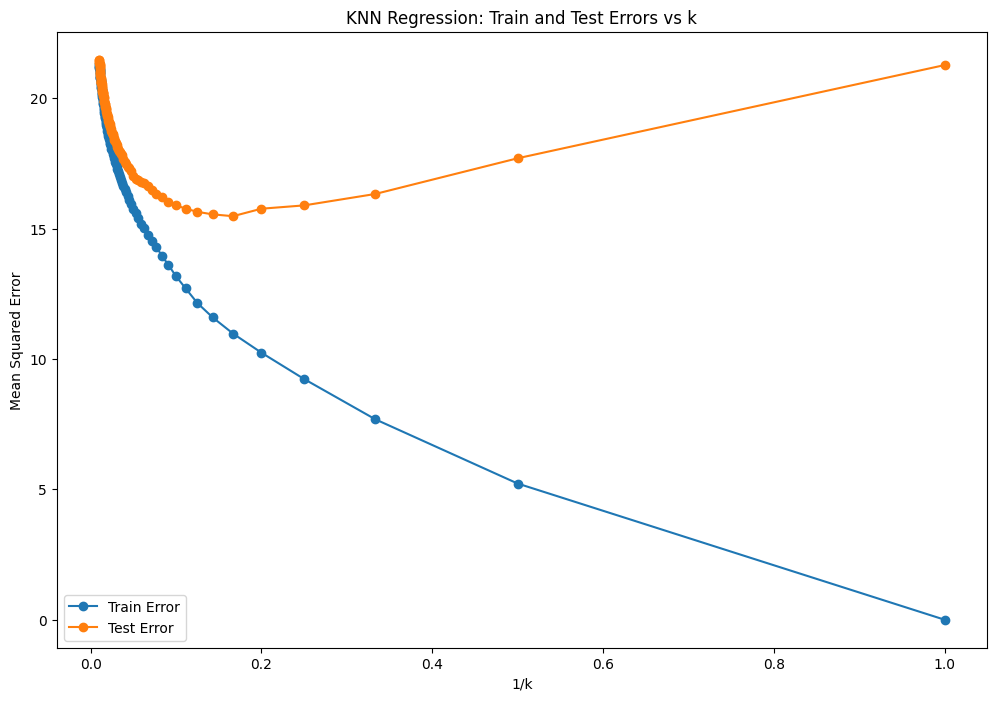

In [59]:
# Case 1: Without Normalization
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(df.drop(columns=['PE']), df['PE'], test_size=0.2)
# print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)
knn_regression(X_train, y_train, X_test, y_test, k_list)

Best k: 7 with Test Error: 16.3711520792016


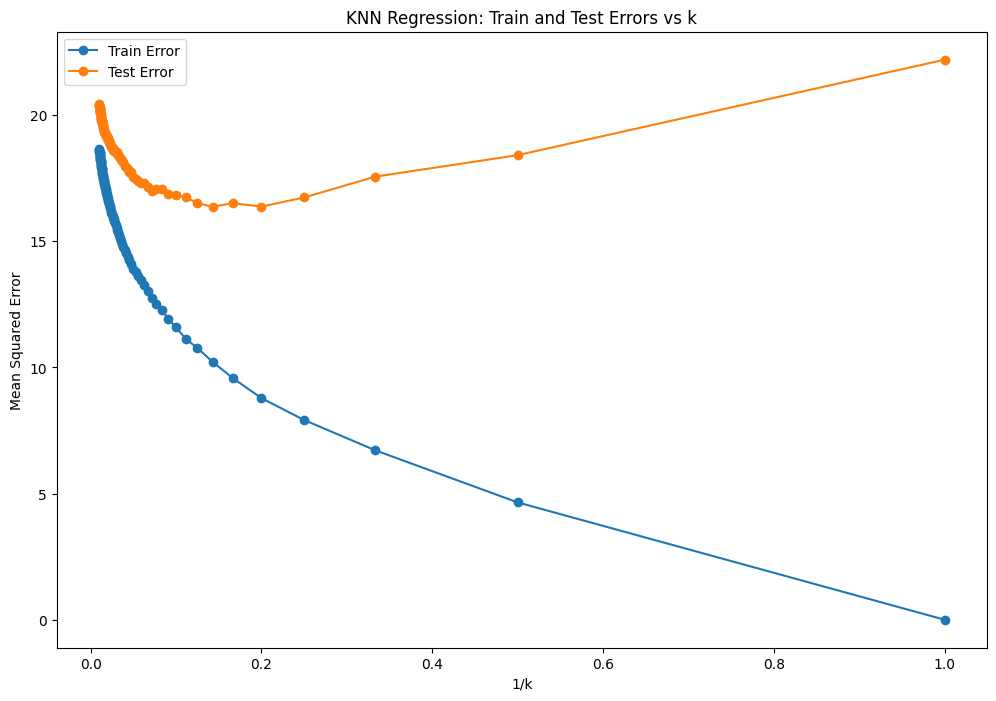

In [60]:
# Case 2: With Normalization
X_train_norm, X_test_norm, y_train, y_test = sklearn.model_selection.train_test_split(sklearn.preprocessing.StandardScaler().fit_transform(df.drop(columns=['PE'])), df['PE'], test_size=0.2)
knn_regression(X_train_norm, y_train, X_test_norm, y_test, k_list)

### j) Compare the results of KNN Regression with the linear regression model that has the smallest test error and provide your analysis.

Answer:

- KNN Regression performs better on the data since it has a lower test error rate
- This might be because the data is difficult to separate linearly and we might need to go to higher dimensional spaces for linear decision boundaries

## 2. For each of parts (a) through (d), indicate whether we would generally expect the performance of a flexible statistical learning method to be better or worse than an inflexible method. Justify your answer.

### a) The sample size n is extremely large, and the number of predictors p is small.

Answer:

The statistical learning method will perform better since it will adjust the patterns according to the observations compared to an inflexible method, which will underfit

### b) The number of predictors p is extremely large, and the number of observations n is small.

Answer:

Inflexible method might be better in this case since statistical learning methods might suffer from overfitting on the small sample of data

### c) The relationship between the predictors and response is highly non-linear.

Answer:

Statistical learning methods (e.g. Neural Networks) perform very well in this case while inflexible methods cannot model the relationship well

### d) The variance of the error terms, i.e. σ^2 = Var(ϵ), is extremely high.

Answer:

Since the data is noisy a statistical learning method cannot capture the relationship well here and an inflexible method might be better

## 3. The table below provides a training data set containing six observations, three predictors, and one qualitative response variable.

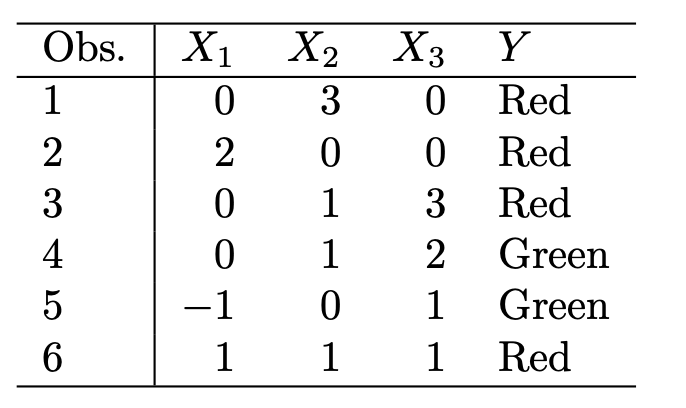

Suppose we wish to use this data set to make a prediction for Y when X1 = X2 = X3 = 0 using K-nearest neighbors.

### a) Compute the Euclidean distance between each observation and the test point, X1 = X2 = X3 = 0.

In [61]:
training_set = pd.DataFrame({
    "X1": [0, 2, 0, 0, -1, 1],
    "X2": [3, 0, 1, 1, 0, 1],
    "X3": [0, 0, 3, 2, 1, 1],
    "Y": ["Red", "Red", "Red", "Green", "Green", "Red"]
})

# display(training_set)

test_point = [0, 0, 0]
euclidean_distances = sklearn.metrics.pairwise.euclidean_distances(training_set[training_set.columns[:-1]], [test_point])

for i in range(len(training_set)):
    print(f"Distance from test point to training point {i}: {euclidean_distances[i][0]}")


Distance from test point to training point 0: 3.0
Distance from test point to training point 1: 2.0
Distance from test point to training point 2: 3.1622776601683795
Distance from test point to training point 3: 2.23606797749979
Distance from test point to training point 4: 1.4142135623730951
Distance from test point to training point 5: 1.7320508075688772


### b) What is our prediction with K = 1? Why?

Answer:

According to the euclidean distances, the test point is closest to training point 4 (Green). So if we use K = 1 for the nearest neighbors classifier, the test point would be classified as Green.

### c) What is our prediction with K = 3? Why?

Answer:

The three nearest points to the test point are training points 1 (Red), 4 (Green) and 5 (Red). Let us say we use majority polling in this case to assign the label, so the assigned label will be Red.

### d) If the Bayes decision boundary in this problem is highly non-linear, then would we expect the best value for K to be large or small? Why?

Answer:

When the decision boundary is highly non-linear or wiggly, the classifier considers less number of points to decide. So the value of K must be small.

## References:

- https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.OLS.html#statsmodels.regression.linear_model.OLS
- https://scikit-learn.org/stable/modules/generated/sklearn.metrics.pairwise.euclidean_distances.html
- https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html#kneighborsregressor
- https://hastie.su.domains/ISLR2/ISLRv2_corrected_June_2023.pdf.download.html